In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio

def process_oxford_mega_mat(file_path):
    extracted_cycles = []
    try:
        mat = sio.loadmat(file_path)
        cell_keys = [k for k in mat.keys() if 'Cell' in k]
        for cell_key in cell_keys:
            cell_data = mat[cell_key] 
            cycle_names = [n for n in cell_data.dtype.names if 'cyc' in n]
            for cyc in cycle_names:
                try:
                    cyc_data = cell_data[cyc][0, 0]
                    if 'C1dc' not in cyc_data.dtype.names: continue 
                    core_data = cyc_data['C1dc'][0, 0]
                    
                    time = core_data['t'][0, 0].flatten()
                    if len(time) < 2: continue 
                    
                    voltage = core_data['v'][0, 0].flatten()
                    temp = core_data['T'][0, 0].flatten() 
                    q_val = core_data['q'][0, 0].flatten()
                    
                    current = q_val 
                    c_rate = current / 0.74 
                    
                    extracted_cycles.append({
                        'Source': 'Oxford',
                        'File_Name': f"{os.path.basename(file_path)}_{cell_key}_{cyc}", 
                        'Cycle_Duration_sec': time[-1] - time[0],
                        'V_max': np.max(voltage), 'V_min': np.min(voltage), 'V_mean': np.mean(voltage),
                        'C_rate_max': np.max(c_rate), 'C_rate_min': np.min(c_rate), 'C_rate_mean': np.mean(c_rate),
                        'Temp_max': np.max(temp), 'Temp_mean': np.mean(temp),
                        'Target_Capacity_Ah': np.max(np.abs(q_val)) / 1000.0
                    })
                except Exception: continue
        return extracted_cycles
    except Exception as e: return []

def process_lghg2_mat(file_path):
    try:
        mat = sio.loadmat(file_path)
        meas = mat['meas']
        time = meas['Time'][0][0].flatten()
        if len(time) < 2: return [] 
        
        voltage = meas['Voltage'][0][0].flatten()
        current = meas['Current'][0][0].flatten()
        
        if 'Battery_Temp_degC' in meas.dtype.names: temp = meas['Battery_Temp_degC'][0][0].flatten()
        elif 'Temperature' in meas.dtype.names: temp = meas['Temperature'][0][0].flatten()
        else: temp = np.zeros_like(time)
            
        c_rate = current / 3.0 
        
        return [{
            'Source': 'LGHG2',
            'File_Name': os.path.basename(file_path),
            'Cycle_Duration_sec': time[-1] - time[0],
            'V_max': np.max(voltage), 'V_min': np.min(voltage), 'V_mean': np.mean(voltage),
            'C_rate_max': np.max(c_rate), 'C_rate_min': np.min(c_rate), 'C_rate_mean': np.mean(c_rate),
            'Temp_max': np.max(temp), 'Temp_mean': np.mean(temp),
            'Target_Capacity_Ah': np.trapezoid(np.abs(current), time) / 3600.0
        }]
    except Exception as e: return []

print("BẮT ĐẦU CÀY CUỐC VÀ GỘP DỮ LIỆU...\n")
oxford_data = [item for f in glob.glob("Oxford_Data/**/*.mat", recursive=True) for item in process_oxford_mega_mat(f)]
lg_data = [item for f in glob.glob("LG_Data/**/*.mat", recursive=True) for item in process_lghg2_mat(f)]
df_mat = pd.DataFrame(oxford_data + lg_data)

df_csv1 = pd.read_csv('Battery_dataset.csv') if os.path.exists('Battery_dataset.csv') else pd.DataFrame()
if not df_csv1.empty:
    df_csv1 = df_csv1.rename(columns={'chV': 'V_max', 'disV': 'V_min', 'chT': 'Temp_max', 'disT': 'Temp_mean', 'BCt': 'Target_Capacity_Ah'})
    df_csv1['C_rate_mean'] = df_csv1['chI']
    df_csv1['Source'] = 'CSV_1'

df_csv2 = pd.read_csv('ev_battery_charging_data.csv') if os.path.exists('ev_battery_charging_data.csv') else pd.DataFrame()
if not df_csv2.empty:
    df_csv2 = df_csv2.rename(columns={'Voltage (V)': 'V_mean', 'Battery Temp (°C)': 'Temp_mean', 'Charging Duration (min)': 'Cycle_Duration_sec'})
    df_csv2['Cycle_Duration_sec'] *= 60
    df_csv2['C_rate_mean'] = df_csv2['Current (A)']
    df_csv2['Target_Capacity_Ah'] = 3.0 * (df_csv2['SOC (%)'] / 100)
    df_csv2['Source'] = 'CSV_2'

master_df = pd.concat([df_mat, df_csv1, df_csv2], axis=0, ignore_index=True).fillna(0)
master_df = master_df[(master_df['Target_Capacity_Ah'] > 0) & (master_df['Target_Capacity_Ah'] <= 3.5)]

master_df.to_csv('Master_Battery_Dataset.csv', index=False)
print(f"🎉 Đã tạo thành công Master Dataset SẠCH! TỔNG KÍCH THƯỚC: {master_df.shape[0]} dòng.")

BẮT ĐẦU CÀY CUỐC VÀ GỘP DỮ LIỆU...

🎉 Đã tạo thành công Master Dataset SẠCH! TỔNG KÍCH THƯỚC: 2350 dòng.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


⏳ Đang nạp và xử lý dữ liệu...

🌲 Đang huấn luyện Random Forest...
🧠 Đang huấn luyện Mạng Nơ-ron (DNN)...

📊 BÁO CÁO ĐÁNH GIÁ MÔ HÌNH HYBRID TRÊN TẬP TEST:
--------------------------------------------------
🔹 Hệ số xác định (R²):       0.6238
🔹 Sai số toàn phương (RMSE): 0.4594 Ah
🔹 Sai số tuyệt đối (MAE):    0.3313 Ah
--------------------------------------------------

✅ Đã lưu trữ thành công RF, DNN và Scaler!


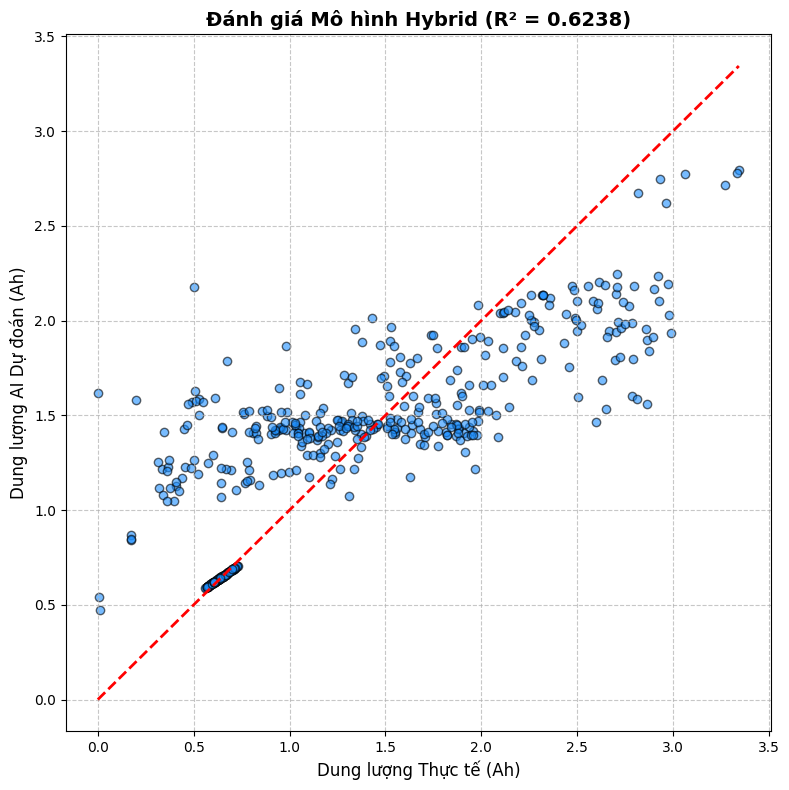

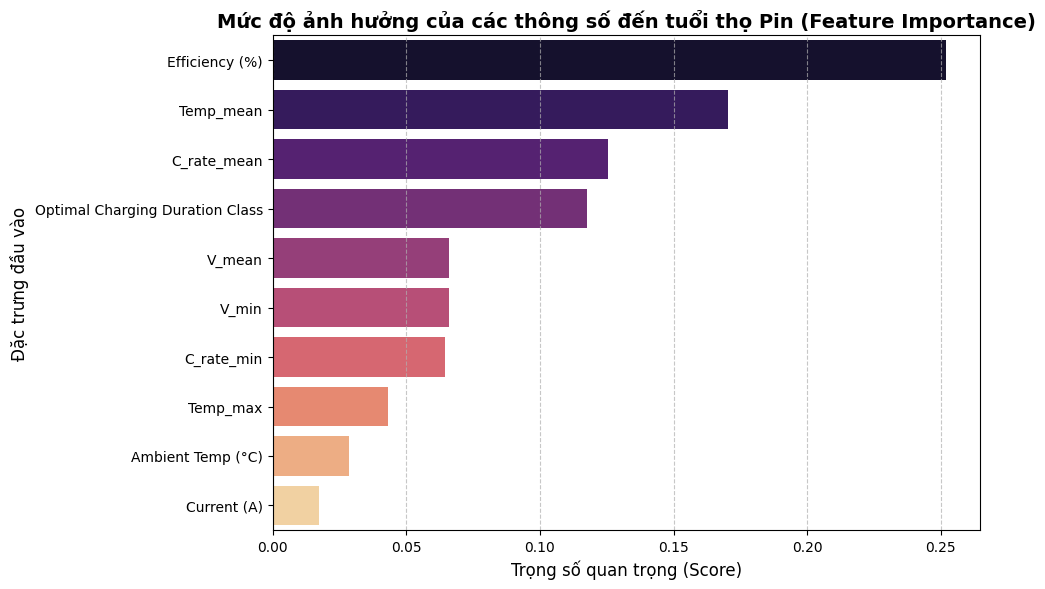

In [3]:
import sys
!{sys.executable} -m pip install -q seaborn matplotlib pandas scikit-learn torch joblib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================
# 1. NẠP VÀ XỬ LÝ DỮ LIỆU SẠCH
# ==========================================
print("⏳ Đang nạp và xử lý dữ liệu...")
master_df = pd.read_csv('Master_Battery_Dataset.csv').dropna(subset=['Target_Capacity_Ah'])

cols_to_drop = ['Target_Capacity_Ah', 'SOH', 'SOC (%)', 'RUL', 'battery_id', 'Source', 
                'File_Name', 'Cycle_Duration_sec', 'cycle', 'Charging Cycles', 'Degradation Rate (%)']

X_raw = master_df.drop(columns=[col for col in cols_to_drop if col in master_df.columns])
X = X_raw.select_dtypes(include=['number']).fillna(0)
y = master_df['Target_Capacity_Ah']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. HUẤN LUYỆN RANDOM FOREST
# ==========================================
print("\n🌲 Đang huấn luyện Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# ==========================================
# 3. HUẤN LUYỆN MẠNG NƠ-RON (DNN)
# ==========================================
print("🧠 Đang huấn luyện Mạng Nơ-ron (DNN)...")
class BatteryDNN(nn.Module):
    def __init__(self, input_dim):
        super(BatteryDNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

input_dim = X_train_scaled.shape[1]
dnn_model = BatteryDNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

dnn_model.train()
for epoch in range(150): 
    optimizer.zero_grad()
    predictions = dnn_model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()

dnn_model.eval()
with torch.no_grad():
    y_pred_dnn = dnn_model(X_test_t).numpy().flatten()

# ==========================================
# 4. ĐÁNH GIÁ MÔ HÌNH HYBRID (RF + DNN)
# ==========================================
y_pred_hybrid = (y_pred_rf + y_pred_dnn) / 2

r2 = r2_score(y_test, y_pred_hybrid)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
mae = mean_absolute_error(y_test, y_pred_hybrid)

print("\n📊 BÁO CÁO ĐÁNH GIÁ MÔ HÌNH HYBRID TRÊN TẬP TEST:")
print("-" * 50)
print(f"🔹 Hệ số xác định (R²):       {r2:.4f}")
print(f"🔹 Sai số toàn phương (RMSE): {rmse:.4f} Ah")
print(f"🔹 Sai số tuyệt đối (MAE):    {mae:.4f} Ah")
print("-" * 50)

# ==========================================
# 5. LƯU MÔ HÌNH ĐỂ ĐƯA VÀO MAIN.PY
# ==========================================
joblib.dump(rf_model, 'master_battery_rf_model.pkl')
joblib.dump(scaler, 'master_battery_scaler.pkl')
torch.save(dnn_model.state_dict(), 'master_battery_dnn.pth')
print("\n✅ Đã lưu trữ thành công RF, DNN và Scaler!")

# ==========================================
# 6. VẼ BIỂU ĐỒ ĐÁNH GIÁ 
# ==========================================
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_hybrid, alpha=0.6, color='dodgerblue', edgecolor='k')
max_val = max(y_test.max(), y_pred_hybrid.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2) 
plt.xlabel('Dung lượng Thực tế (Ah)', fontsize=12)
plt.ylabel('Dung lượng AI Dự đoán (Ah)', fontsize=12)
plt.title(f'Đánh giá Mô hình Hybrid (R² = {r2:.4f})', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# ==========================================
# 7. VẼ BIỂU ĐỒ MỨC ĐỘ ẢNH HƯỞNG CỦA ĐẶC TRƯNG
# ==========================================
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Lấy top 10 đặc trưng quan trọng nhất để biểu đồ đỡ rối
top_n = min(10, len(X.columns))
sorted_features = X.columns[indices][:top_n]
sorted_importances = importances[indices][:top_n]

sns.barplot(x=sorted_importances, y=sorted_features, palette='magma', hue=sorted_features, legend=False)
plt.title('Mức độ ảnh hưởng của các thông số đến tuổi thọ Pin (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số quan trọng (Score)', fontsize=12)
plt.ylabel('Đặc trưng đầu vào', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()